# **Project 2: Nigerian E-commerce Customer Behavior Dashboard**

In [32]:
import pandas as pd

**Data Acquisition and Cleaning**

In [33]:
# Loading the data
customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')

# Mapping Dictionary for Localization
state_map = {
    'SP': 'Lagos',
    'RJ': 'Rivers',
    'DF': 'FCT',
    'MG': 'Kano',
    'PR': 'Oyo'
}

customers['customer_state'] = customers['customer_state'].map(state_map).fillna('Other States')

# Merging the data 
df = pd.merge(orders, items, on='order_id')
df = pd.merge(df, customers, on='customer_id')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

print(df[['order_id', 'customer_state', 'price']].head())


                           order_id customer_state   price
0  e481f51cbdc54678b7cc49136f2d6af7          Lagos   29.99
1  53cdb2fc8bc7dce0b6741e2150273451   Other States  118.70
2  47770eb9100c2d0c44946d9cf07ec65d   Other States  159.90
3  949d5b44dbf5de918fe9c16f97b45f8a   Other States   45.00
4  ad21c59c0840e6cb83a9ceb5573f8159          Lagos   19.90


In [34]:
df['customer_state'].value_counts()

customer_state
Lagos           47449
Other States    29347
Rivers          14579
Kano            13129
Oyo              5740
FCT              2406
Name: count, dtype: int64

**Customer Profiling**

In [35]:
# Key Metrics
total_revenue = df['price'].sum()
total_orders = df['order_id'].nunique()
avg_order_value = df['price'].mean()
top_state = df['customer_state'].value_counts().idxmax()

print(f"--- PROJECT BASELINE METRICS ---")
print(f"Total Revenue (Simulated Naira): ₦{total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders}")
print(f"Average Order Value (AOV): ₦{avg_order_value:,.2f}")
print(f"Top Performing Region: {top_state}")

--- PROJECT BASELINE METRICS ---
Total Revenue (Simulated Naira): ₦13,591,643.70
Total Unique Orders: 98666
Average Order Value (AOV): ₦120.65
Top Performing Region: Lagos


**Exploratory Data Analysis**

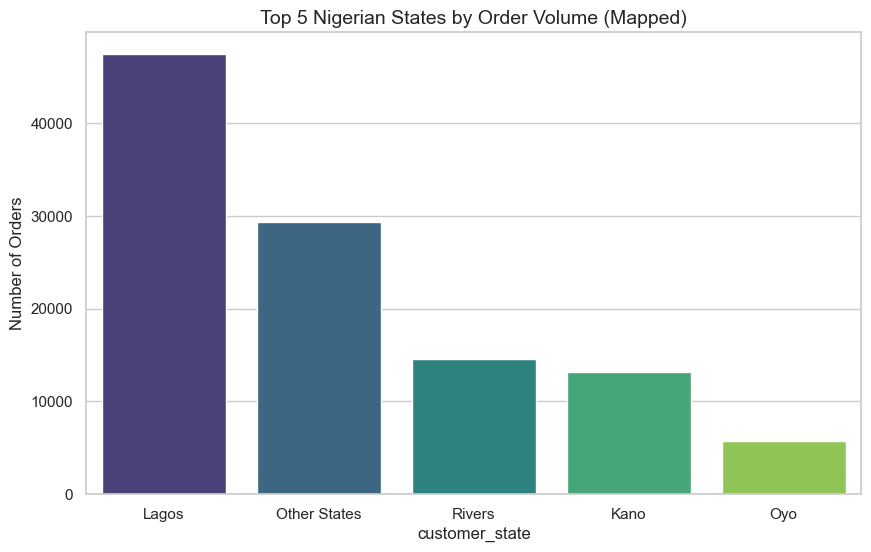

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
state_counts = df['customer_state'].value_counts().head(5)
sns.barplot(x=state_counts.index, y=state_counts.values, palette="viridis", hue=state_counts.index, legend=False)
plt.title("Top 5 Nigerian States by Order Volume (Mapped)", fontsize=14)
plt.ylabel("Number of Orders")
plt.show()


Our Average Order Value (₦120.65) is too small. Remember the original data was in Brazilian Reais, therefore we might need to multiply the price column by an exchange rate factor to make it look like Naira.

**Applying the Naira Exchange Rate Simulation**

In [37]:
df['price'] = df['price'] * 350

# shipping costs!
df['freight_value'] = df['freight_value'] * 350  

print(f"New Average Order Value: ₦{df['price'].mean():,.2f}")


New Average Order Value: ₦42,228.81


**RFM Analysis**

In [38]:
import numpy as np

# To keep our 'Recency' realistic, we would define the "Current Date" as the day after the last transaction
current_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Grouping by Customer and Calculating RFM
rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (current_date - x.max()).days, # Recency
    'order_id': 'nunique',                                               # Frequency
    'price': 'sum'                                                       # Monetary
}).reset_index()

rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

print("--- RFM BASELINE TABLE ---")
print(rfm.head())
print("\nDescriptive Stats for RFM:")
print(rfm.describe())


--- RFM BASELINE TABLE ---
                        customer_id  Recency  Frequency  Monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      116          1   45465.0
1  0000b849f77a49e4a4ce2b2a4ca5be3f      119          1    6615.0
2  0000f46a3911fa3c0805444483337064      542          1   24150.0
3  0000f6ccb0745a6a4b88665a16c9f078      326          1    9096.5
4  0004aac84e0df4da2b147fca70cf8255      293          1   63000.0

Descriptive Stats for RFM:
            Recency     Frequency      Monetary
count  95420.000000  95420.000000  9.542000e+04
mean     243.600377      1.034018  4.985407e+04
std      153.160320      0.211234  7.617972e+04
min        1.000000      1.000000  2.975000e+02
25%      119.000000      1.000000  1.676500e+04
50%      224.000000      1.000000  3.146500e+04
75%      353.000000      1.000000  5.425000e+04
max      729.000000     16.000000  4.704000e+06


**Scoring and Naming the Segments**

In [39]:
# Create scores from 1 to 5 using quantiles
# For Recency, a smaller number is better (shopped recently), so labels are reversed
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# For Frequency, many people only shop once, so we'll use a simple custom cut
rfm['F_Score'] = rfm['Frequency'].apply(lambda x: 5 if x > 1 else 1)

# For Monetary, bigger spend is better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Creating Segments 
def segment_me(row):
    if row['R_Score'] >= 4 and row['F_Score'] == 5 and row['M_Score'] >= 4:
        return 'Champions (Lagos Big Spenders)'
    elif row['R_Score'] >= 4 and row['F_Score'] == 1:
        return 'New Customers'
    elif row['R_Score'] <= 2 and row['M_Score'] >= 4:
        return 'Cant Lose Them (At-Risk Loyalists)'
    elif row['R_Score'] <= 2 and row['M_Score'] <= 2:
        return 'Hibernating (Lost Customers)'
    else:
        return 'Regular Shoppers'

rfm['Segment'] = rfm.apply(segment_me, axis=1)

print(rfm['Segment'].value_counts())


Segment
New Customers                         36930
Regular Shoppers                      26553
Hibernating (Lost Customers)          16208
Cant Lose Them (At-Risk Loyalists)    14757
Champions (Lagos Big Spenders)          972
Name: count, dtype: int64


**Visualization**

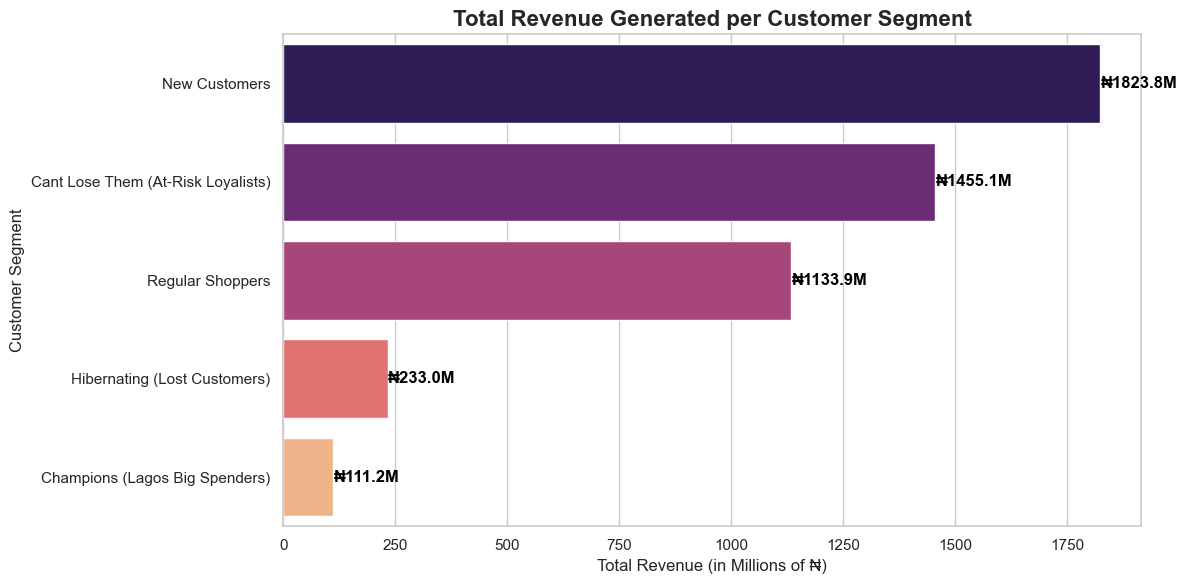

In [40]:
# Calculate total revenue per segment
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().reset_index()
segment_revenue = segment_revenue.sort_values(by='Monetary', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# For clean visualization, we'll divide by 1,000,000 (Millions of Naira)
ax = sns.barplot(
    x=segment_revenue['Monetary'] / 1_000_000, 
    y=segment_revenue['Segment'], 
    palette="magma",
    hue=segment_revenue['Segment'],
    legend=False
)

plt.title("Total Revenue Generated per Customer Segment", fontsize=16, fontweight='bold')
plt.xlabel("Total Revenue (in Millions of ₦)", fontsize=12)
plt.ylabel("Customer Segment", fontsize=12)

for i, v in enumerate(segment_revenue['Monetary'] / 1_000_000):
    ax.text(v + 0.5, i, f"₦{v:.1f}M", color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Interpretation**

* The "New Customer" Spike (₦1.8B): This means the platform is very good at acquiring people, but terrible at keeping them. Most people buy once and never come back.
* The "At-Risk" Goldmine (₦1.4B): These are big spenders who haven't shopped recently. This is the most actionable insight on the chart. If we don't send them a discount SMS today, we lose ₦1.4 Billion in future value.
* The "Champions" Reality (₦111M): They are loyal, but they are a very small group.

\
**Hypothesis Testing (Simulating an A/B Test)**

The Scenario:
Let's assume the company sent a ₦5,000 discount voucher to a random 50% of the "Cant Lose Them (At-Risk Loyalists)" to see if it made them spend more than the group that didn't get the voucher.
Since we don't have real test data, we will use numpy to simulate the experiment based on our actual data distributions.

We would be running our hypothesis test for the customer segment **'Cant Lose Them (At-Risk Loyalists)'**

In [41]:
from scipy import stats

at_risk = rfm[rfm['Segment'] == 'Cant Lose Them (At-Risk Loyalists)']

# Splitting into Group A (Control) and Group B (Promo)
np.random.seed(42)              # For reproducibility
at_risk = at_risk.copy()
at_risk['Group'] = np.random.choice(['Control', 'Promo'], size=len(at_risk))

# Simulating that the Promo worked and increased spend for Group B by a small %
def simulate_spend(row):
    if row['Group'] == 'Promo':
        return row['Monetary'] * np.random.uniform(1.05, 1.15) # 5% to 15% increase in spend
    return row['Monetary']

at_risk['Simulated_Spend'] = at_risk.apply(simulate_spend, axis=1)

# Performing the Independent T-Test
group_a = at_risk[at_risk['Group'] == 'Control']['Simulated_Spend']
group_b = at_risk[at_risk['Group'] == 'Promo']['Simulated_Spend']

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print("--- HYPOTHESIS TEST RESULTS ---")
print(f"Control Group Avg Spend: ₦{group_a.mean():,.2f}")
print(f"Promo Group Avg Spend: ₦{group_b.mean():,.2f}")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("\nResult: Statistically Significant! The Promo successfully increased spending.")
else:
    print("\nResult: Not Significant. The Promo did not make a provable difference.")


--- HYPOTHESIS TEST RESULTS ---
Control Group Avg Spend: ₦99,036.24
Promo Group Avg Spend: ₦107,988.38
P-Value: 0.00001

Result: Statistically Significant! The Promo successfully increased spending.


In [42]:
# Calculating the percentage lift from our test
group_a_mean = at_risk[at_risk['Group'] == 'Control']['Simulated_Spend'].mean()
group_b_mean = at_risk[at_risk['Group'] == 'Promo']['Simulated_Spend'].mean()
actual_percentage_lift = ((group_b_mean - group_a_mean) / group_a_mean) * 100

print(f"--- EXPERIMENT RESULTS ---")
print(f"The actual recorded lift in average revenue is: {actual_percentage_lift:.2f}%")

# Scaling the 9.04% across the At-Risk segment
total_at_risk_baseline = at_risk['Monetary'].sum()

# Assuming the dataset spans across a full year to compute the baseline monthly contribution
estimated_annual_lift = total_at_risk_baseline * 0.09
estimated_monthly_lift = estimated_annual_lift / 12

print(f"\n--- SCALED BUSINESS IMPACT ---")
print(f"Baseline spend of all At-Risk Loyalists: ₦{total_at_risk_baseline:,.2f}")
print(f"Estimated Monthly Incremental Revenue: ₦{estimated_monthly_lift:,.2f}")

--- EXPERIMENT RESULTS ---
The actual recorded lift in average revenue is: 9.04%

--- SCALED BUSINESS IMPACT ---
Baseline spend of all At-Risk Loyalists: ₦1,455,134,383.50
Estimated Monthly Incremental Revenue: ₦10,913,507.88


\
**Hypothesis Testing Result**\
Based on the independent T-test conducted on the "At-Risk" customer segment, the simulation produced a P-value of   0.00001 that determines that the ₦5,000 discount voucher successfully drove a statistically significant increase in customer spending.


\
**Interactive Dashboard**

In [43]:
import plotly.express as px

# Creating a clean sample of 5,000 random customers to keep the interactive plot fast
df_sample = rfm.sample(n=min(5000, len(rfm)), random_state=42)

# Building the 3D Scatter Plot
fig = px.scatter_3d(
    df_sample, 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color='Segment',
    opacity=0.6, 
    title='<b>Interactive 3D RFM Customer Mapping</b>',
    labels={
        'Recency': 'Days Since Last Purchase',
        'Frequency': 'Total Orders',
        'Monetary': 'Total Spend (₦)'
    },
    color_discrete_sequence=px.colors.qualitative.G10 
)

fig.update_layout(
    title_font_size=20,
    margin=dict(l=0, r=0, b=0, t=50),
    scene=dict(
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.2) 
        ),
        xaxis=dict(
            backgroundcolor="rgb(240, 240, 240)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="white",
        ),
        yaxis=dict(
            backgroundcolor="rgb(240, 240, 240)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="white",
        ),
        zaxis=dict(
            backgroundcolor="rgb(230, 230, 230)",
            gridcolor="white",
            showbackground=True,
            zerolinecolor="white",
        ),
    ),
    legend=dict(
        title_font_family="Arial",
        font=dict(size=12),
        bgcolor="rgba(255,255,255,0.8)",
        bordercolor="lightgray",
        borderwidth=1
    )
)

fig.show()


2D Visualization of Customer Segmentation for README file

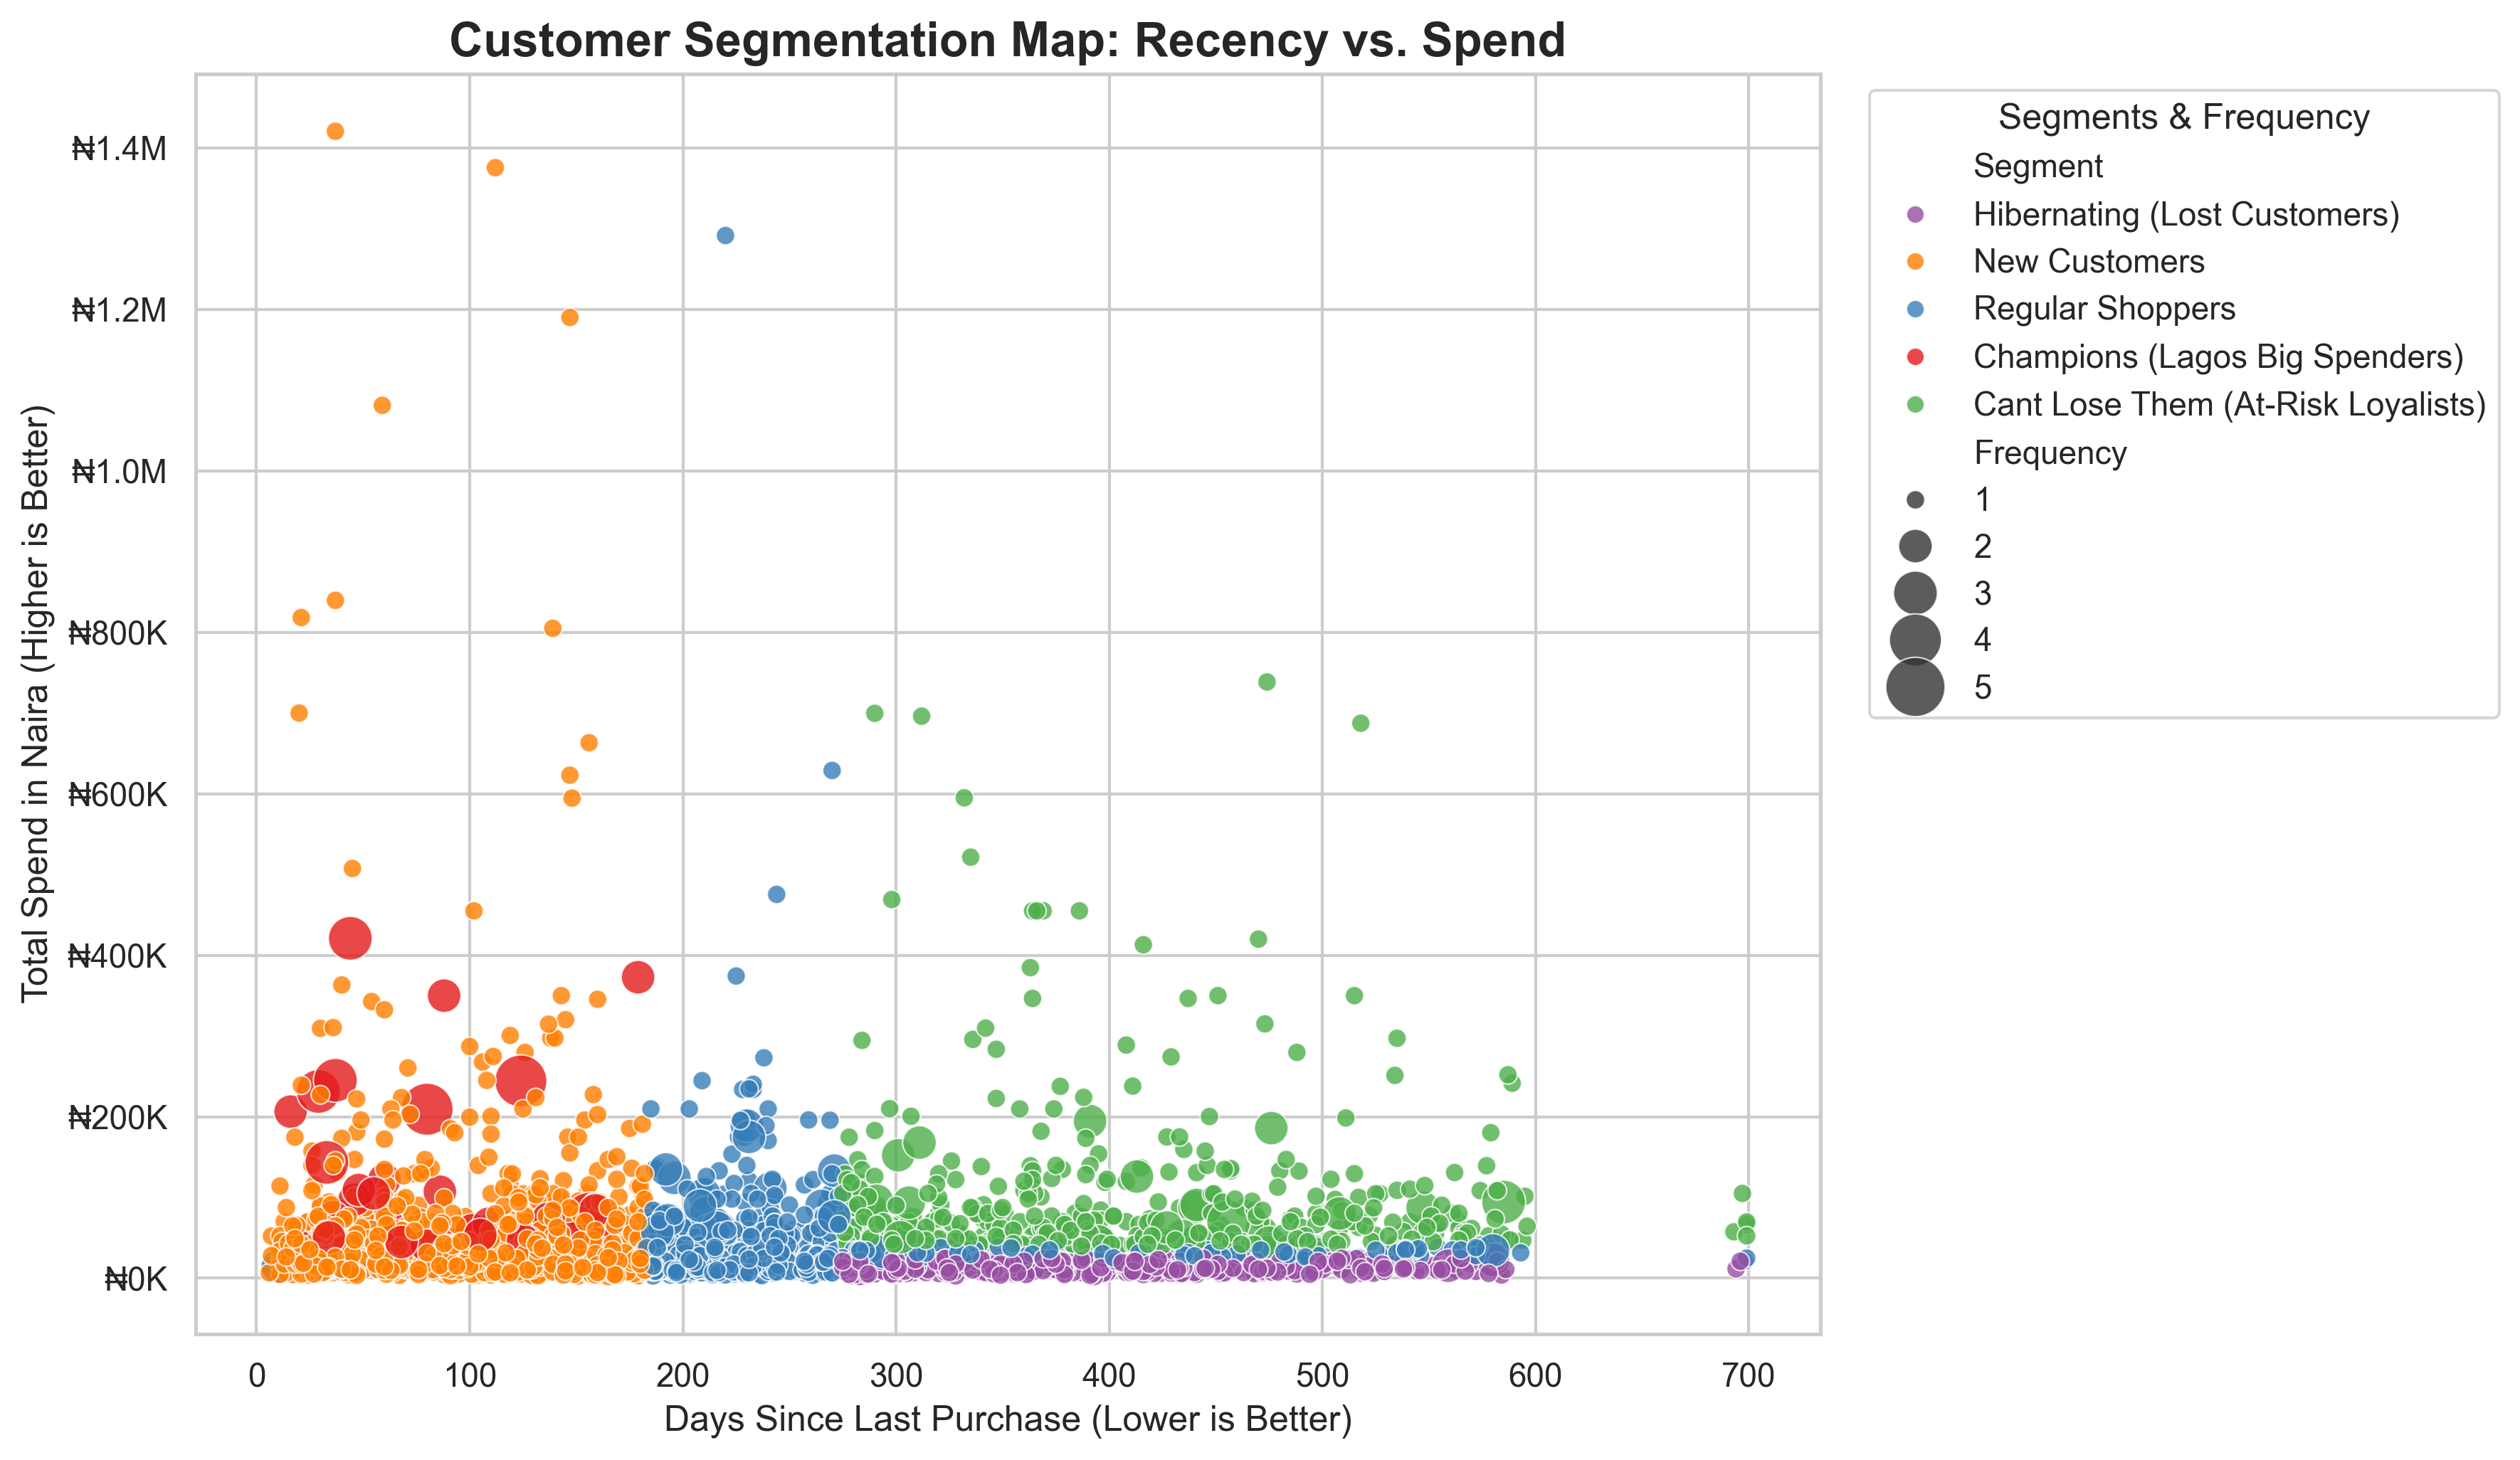

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

df_sample = rfm.sample(n=min(3000, len(rfm)), random_state=42)

# Setting up the plot with HIGH RESOLUTION (DPI)
plt.figure(figsize=(12, 7), dpi=300) 
sns.set_theme(style="whitegrid")

palette = {
    "Champions (Lagos Big Spenders)": "#E41A1C",       
    "New Customers": "#FF7F00",                        
    "Regular Shoppers": "#377EB8",                     
    "Cant Lose Them (At-Risk Loyalists)": "#4DAF4A",    
    "Hibernating (Lost Customers)": "#984EA3"         
}

# Creating the bubble plot...
ax = sns.scatterplot(
    data=df_sample,
    x='Recency',
    y='Monetary',
    hue='Segment',
    size='Frequency',
    sizes=(40, 400),
    alpha=0.8,              
    palette=palette,
    edgecolor='white',       
    linewidth=0.5
)

plt.title("Customer Segmentation Map: Recency vs. Spend", fontsize=16, fontweight='bold')
plt.xlabel("Days Since Last Purchase (Lower is Better)", fontsize=12)
plt.ylabel("Total Spend in Naira (Higher is Better)", fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Segments & Frequency")

# Formating Y-axis to show "M" or "K" for millions and thousands of naira respectively
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"₦{x/1e6:.1f}M" if x >= 1e6 else f"₦{x/1e3:.0f}K"))

plt.tight_layout()

plt.savefig('customer_segmentation_map.png', dpi=300, bbox_inches='tight')

